### Stage 03: Model Refinement and Advanced Tuning

**Project Overview:**  
This stage refines regression models for used car price prediction through **5-fold cross-validation**, **polynomial feature engineering**, **Ridge regularization**, and **Grid Search hyperparameter optimization**. The goal is to achieve robust generalization and minimize overfitting.

---


##### Load & Inspect Dataset

In [1]:
# Load & Inspect Dataset

import pandas as pd

df = pd.read_csv("../data/usedcars.csv")
df.head()


,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


📍 **Dataset Location Note**: The dataset is now centrally stored in the `data/` folder at the project root. All notebooks load from `../data/usedcars.csv` for consistency and easier maintenance.

In [2]:
from pathlib import Path
import json
import pandas as pd

STAGE1_DATA_PATH = Path("..").resolve() / "01-eda" / "outputs" / "processed" / "usedcars_stage1.csv"
DATA_SOURCE_PATH = STAGE1_DATA_PATH if STAGE1_DATA_PATH.exists() else Path("../data/usedcars.csv")
df = pd.read_csv(DATA_SOURCE_PATH)
print(f"Dataset source: {DATA_SOURCE_PATH}")

stage2_metrics_path = Path("..").resolve() / "02-baseline-modeling" / "outputs" / "metrics" / "best_model_metrics.json"
if stage2_metrics_path.exists():
    with stage2_metrics_path.open("r", encoding="utf-8") as f:
        stage2_metrics = json.load(f)
    print("Stage 2 baseline metrics:")
    print(f"  Model: {stage2_metrics.get('best_model', 'n/a')}")
    print(f"  Test R²: {stage2_metrics.get('test_r2', 'n/a')}")
    print(f"  Test RMSE: {stage2_metrics.get('test_rmse', 'n/a')}")
    print(f"  Test MAE: {stage2_metrics.get('test_mae', 'n/a')}")

Dataset source: C:\Users\a12u\OneDrive\Desktop\Courses\Own Projects\used-car-price-intelligence-platform\01-eda\outputs\processed\usedcars_stage1.csv
Stage 2 baseline metrics:
  Model: Gradient Boosting
  Test R²: 0.96048233541031
  Test RMSE: 1841.788643661087
  Test MAE: 1082.2233602468232


In [3]:
# Check column info and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          500 non-null    int64  
 1   normalized-losses  500 non-null    int64  
 2   make               500 non-null    object 
 3   aspiration         500 non-null    object 
 4   num-of-doors       500 non-null    object 
 5   body-style         500 non-null    object 
 6   drive-wheels       500 non-null    object 
 7   engine-location    500 non-null    object 
 8   wheel-base         500 non-null    float64
 9   length             500 non-null    float64
 10  width              500 non-null    float64
 11  height             500 non-null    float64
 12  curb-weight        500 non-null    int64  
 13  engine-type        500 non-null    object 
 14  num-of-cylinders   500 non-null    object 
 15  engine-size        500 non-null    int64  
 16  fuel-system        500 non

In [4]:
# Check missing values
df.isnull().sum()

symboling             0
normalized-losses     0
make                  0
aspiration            0
num-of-doors          0
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  0
stroke               13
compression-ratio     0
horsepower            0
peak-rpm              0
city-mpg              0
highway-mpg           0
price                 0
city-L/100km          0
horsepower-binned     1
diesel                0
gas                   0
dtype: int64

In [5]:
# Summary statistics
df.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,487.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.00000
mean,0.908000,123.876000,98.677327,0.838365,0.914808,53.898306,2549.668000,125.924000,3.320361,3.241899,9.899579,103.253339,5132.318872,24.856000,30.340000,13110.746485,10.042688,0.07800,0.92200
std,1.262824,33.702587,5.930534,0.056997,0.028262,2.478741,493.673439,40.343096,0.268553,0.323122,3.588726,36.455398,467.665873,6.261764,6.521461,7585.958921,2.489609,0.26844,0.26844
min,-2.000000,65.000000,86.600000,0.678039,0.837500,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000,4.795918,0.00000,0.00000
25%,0.000000,102.000000,94.505311,0.801560,0.889670,52.000000,2190.750000,98.000000,3.150000,3.080521,8.600000,70.000000,4800.000000,19.000000,25.000000,7857.238625,7.999271,0.00000,1.00000
50%,1.000000,122.000000,96.973766,0.831810,0.909722,54.289916,2443.000000,119.000000,3.310000,3.285500,9.005129,95.218493,5183.688793,24.000000,30.000000,10587.987879,9.718638,0.00000,1.00000
75%,2.000000,145.000000,101.200000,0.881788,0.926932,55.660806,2910.500000,141.000000,3.550101,3.408257,9.398860,116.000000,5488.638514,29.250000,34.000000,16318.540563,12.334418,0.00000,1.00000
max,3.000000,256.000000,120.900000,1.000000,1.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000,18.076923,1.00000,1.00000


##### Data Cleaning & Preparation

In [6]:
# Drop irrelevant column 'car_id'
if 'car_id' in df.columns:
    df.drop('car_id', axis=1, inplace=True)

# Drop rows with missing target
df.dropna(subset=['price'], inplace=True)

# One-hot encode categorical features
df = pd.get_dummies(df, drop_first=True)

# Separate target and features
y_data = df['price']
x_data = df.drop('price', axis=1)


In [7]:
df.head()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,...,num-of-cylinders_two,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi,horsepower-binned_Low,horsepower-binned_Medium
0,3,122,88.6,0.811148,0.890278,48.8,2548,130,3.47,2.68,...,False,False,False,False,False,True,False,False,False,True
1,3,122,88.6,0.811148,0.890278,48.8,2548,130,3.47,2.68,...,False,False,False,False,False,True,False,False,False,True
2,1,122,94.5,0.822681,0.909722,52.4,2823,152,2.68,3.47,...,False,False,False,False,False,True,False,False,False,True
3,2,164,99.8,0.848630,0.919444,54.3,2337,109,3.19,3.40,...,False,False,False,False,False,True,False,False,False,True
4,2,164,99.4,0.848630,0.922222,54.3,2824,136,3.19,3.40,...,False,False,False,False,False,True,False,False,False,True


##### Train/Test Split
We split the dataset into **training** (90%) and **testing** (10%) sets.


In [8]:
from sklearn.model_selection import train_test_split

# Fill numeric NaNs with the column mean
x_data = x_data.fillna(x_data.mean())

x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.1, random_state=1)


##### Baseline Linear Regression
We start with a simple Linear Regression model to set a baseline performance.


In [9]:
from sklearn.linear_model import LinearRegression

lre = LinearRegression()
lre.fit(x_train, y_train)

print("Train R²:", lre.score(x_train, y_train))
print("Test R²:", lre.score(x_test, y_test))

Train R²: 0.9742734888882681
Test R²: 0.9759184331416035


##### Cross-Validation
We use 5-fold cross-validation to ensure performance is consistent across different data splits.


In [10]:
from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(lre, x_data, y_data, cv=5)
print("Mean R²:", scores.mean())
print("Std deviation:", scores.std())

Mean R²: 0.959109579812831
Std deviation: 0.015191512668258795


##### Polynomial Features + Ridge Regression
Polynomial features allow the model to capture non-linear patterns,while Ridge regression helps prevent overfitting.


In [11]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

# Pipeline with scaling, polynomial expansion, and ridge regression
model = Pipeline([
    ('scale', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2)),
    ('ridge', Ridge(alpha=1))
])

model.fit(x_train, y_train)
print("Train R²:", model.score(x_train, y_train))
print("Test R²:", model.score(x_test, y_test))


Train R²: 0.9978061330739112
Test R²: 0.9663436207581019


##### Grid Search for Best Hyperparameters
We use Grid Search to find the best `alpha` for Ridge regression.


In [12]:
from sklearn.model_selection import GridSearchCV

# Create pipeline for consistent preprocessing
pipeline = Pipeline([
    ('scale', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2)),
    ('ridge', Ridge())
])

# Grid search over ridge alpha parameter
param_grid = {'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2')
grid_search.fit(x_data, y_data)

print("Best alpha:", grid_search.best_params_['ridge__alpha'])
print("Best CV R² score:", grid_search.best_score_)


Best alpha: 10
Best CV R² score: 0.976379275005453


##### Model Evaluation
We evaluate the best model using R² and Mean Squared Error (MSE).


In [13]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

y_pred = grid_search.predict(x_test)
print("Test R² score:", r2_score(y_test, y_pred))
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test MAE:", mean_absolute_error(y_test, y_pred))


Test R² score: 0.9971063609212344
Test MSE: 181295.95406582512
Test MAE: 262.08318651789597


##### Visualization of Predictions
We visualize predicted vs. actual prices and residuals.


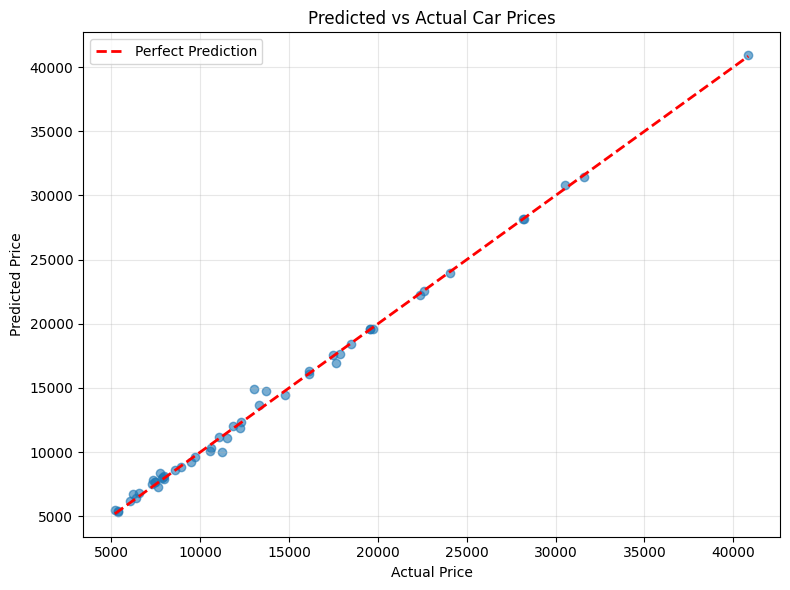

In [14]:
import matplotlib.pyplot as plt
import os

# Create outputs/figures directory if it doesn't exist
os.makedirs("outputs/figures", exist_ok=True)

# Predicted vs Actual
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.6)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel("Actual Price")
ax.set_ylabel("Predicted Price")
ax.set_title("Predicted vs Actual Car Prices")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/figures/predicted_vs_actual.png", dpi=300, bbox_inches='tight')
plt.show()

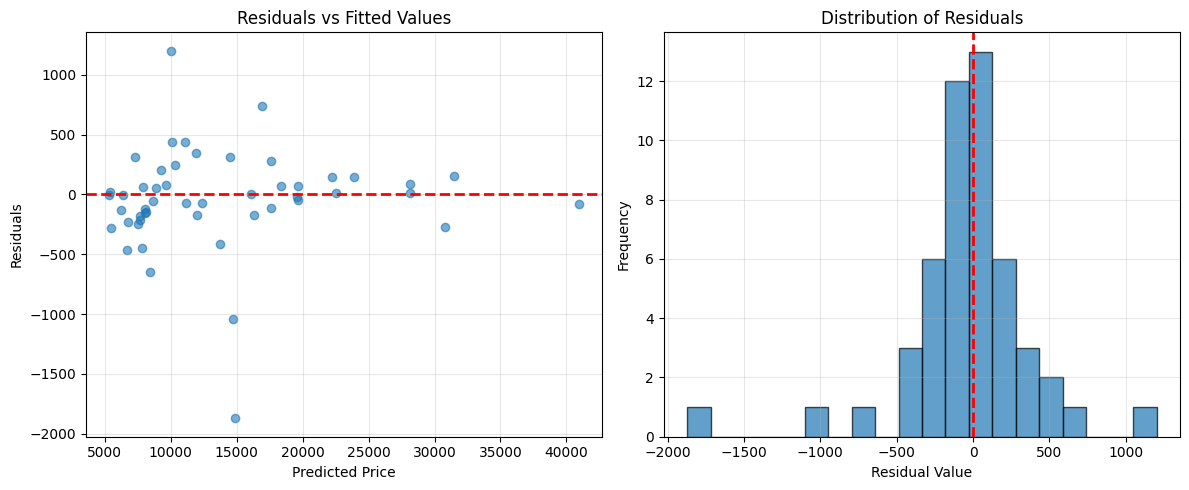

In [15]:
# Residual Plot  
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Residuals vs Fitted Values
residuals = y_test - y_pred
axes[0].scatter(y_pred, residuals, alpha=0.6)
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel("Predicted Price")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted Values")
axes[0].grid(True, alpha=0.3)

# Plot 2: Distribution of Residuals
axes[1].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
axes[1].set_xlabel("Residual Value")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Residuals")
axes[1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/figures/residual_diagnostics.png", dpi=300, bbox_inches='tight')
plt.show()


In this project, we successfully built and refined regression models to predict used car prices.  
Key steps included:  
- Data cleaning and preparation  
- Train/Test splitting  
- Baseline Linear Regression  
- Cross-validation for model reliability  
- Polynomial feature expansion with Ridge regression to capture non-linear patterns  
- Hyperparameter tuning using Grid Search  

The final model demonstrated strong predictive performance, as shown by evaluation metrics and visualizations.  

Author - Visura Rodrigo


